# Анализ ценообразования такси


### О коде
Подготовка данных и оценка модели с помощью линейной регрессии

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

##Табличные данные

In [ ]:
path = kagglehub.dataset_download("mlfool/yandex-taxi-saint-petersburg")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'yandex-taxi-saint-petersburg' dataset.
Path to dataset files: /kaggle/input/yandex-taxi-saint-petersburg


In [ ]:
df=pd.read_csv(path+'/spb_taxi_dataset.csv')

In [ ]:
df.head()

,Date and time of start of the trip,Coordinate of start of the trip,Coordinate of end of the trip,Length of the trip,Weather,Time in a day,Day of the week,Demand,Cost,start_lat,start_lon,end_lat,end_lon
0,2024-11-11 23:55:20,"(59.937390, 30.360035)","(59.804680, 30.279073)",15.516803,cloudy,evening,Saturday,-0.210378,896.256161,59.937390,30.360035,59.804680,30.279073
1,2024-11-03 03:15:55,"(59.930425, 30.358578)","(59.924898, 30.353040)",0.851690,cloudy,night,Friday,-0.083528,339.144060,59.930425,30.358578,59.924898,30.353040
2,2024-11-15 10:32:41,"(59.942846, 30.299823)","(59.793490, 30.249374)",19.258305,sunny,morning,Wednesday,-0.072508,1013.955708,59.942846,30.299823,59.793490,30.249374
3,2024-11-26 10:16:48,"(59.935855, 30.304162)","(59.806697, 30.277012)",15.040192,snow,morning,Sunday,-0.590949,960.604227,59.935855,30.304162,59.806697,30.277012
4,2024-11-30 05:40:54,"(59.971625, 30.307775)","(59.929293, 30.356130)",6.396713,cloudy,night,Thursday,-0.065995,511.358728,59.971625,30.307775,59.929293,30.356130


Сделаем dummy - переменную `weekend`, которая будет отражать день недели: выходной - 1, рабочий - 0

In [ ]:
df['weekend'] = df['Day of the week'].isin(['Saturday', 'Sunday']).astype(int)

Выберем переменные, которые будут включены в экономическую модель

In [ ]:
data=df[['Cost','Length of the trip','Demand','Weather','Time in a day','weekend']]
data = pd.get_dummies(data, drop_first=True) #для категориальных признаков сразу создадим dummy переменные

In [ ]:
data[['Weather_rain','Weather_snow','Weather_sunny','Time in a day_evening','Time in a day_morning','Time in a day_night']]=data[['Weather_rain','Weather_snow','Weather_sunny','Time in a day_evening','Time in a day_morning','Time in a day_night']].astype(int)

In [ ]:
data.head()

,Cost,Length of the trip,Demand,weekend,Weather_rain,Weather_snow,Weather_sunny,Time in a day_evening,Time in a day_morning,Time in a day_night
0,896.256161,15.516803,-0.210378,1,0,0,0,1,0,0
1,339.144060,0.851690,-0.083528,0,0,0,0,0,0,1
2,1013.955708,19.258305,-0.072508,0,0,0,1,0,1,0
3,960.604227,15.040192,-0.590949,1,0,1,0,0,1,0
4,511.358728,6.396713,-0.065995,0,0,0,0,0,0,1


##EDA

###Общий анализ

In [ ]:
data.shape

(8000, 10)

Пропуски по переменным

In [ ]:
data.isna().sum()

,0
Cost,19
Length of the trip,30
Demand,0
weekend,0
Weather_rain,0
Weather_snow,0
Weather_sunny,0
Time in a day_evening,0
Time in a day_morning,0
Time in a day_night,0


Можем заметить, что есть nan в переменной `Сost` и `Length of the trip`, так как у нас 8000 данных, то мы не сильно потеряем точность, если не будет учитывать примеры с nan, поэтому удаляем строки, в которых они содержатся

In [ ]:
data=data.dropna()
data.shape #проверяем сколько данных у нас осталось

(7951, 10)

In [ ]:
df1=df[['Cost', 'Length of the trip', 'Demand']].describe()
df1

,Cost,Length of the trip,Demand
count,7981.000000,7970.000000,8000.000000
mean,678.968480,10.169765,-0.164096
std,271.311174,7.637431,0.179531
min,320.000000,0.500000,-0.978502
25%,444.035470,3.486994,-0.160089
50%,627.869515,8.686178,-0.102801
75%,893.441316,16.499148,-0.079488
max,1603.828593,32.018432,-0.048198


In [ ]:
df[['Cost', 'Length of the trip', 'Demand']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cost                7981 non-null   float64
 1   Length of the trip  7970 non-null   float64
 2   Demand              8000 non-null   float64
dtypes: float64(3)
memory usage: 187.6 KB


In [ ]:
df1.to_excel('Describe.xlsx', sheet_name='Describe', index=True)

###Анализ и подготовка непрерыных переменных

####Cтоимость поездки (Cost)

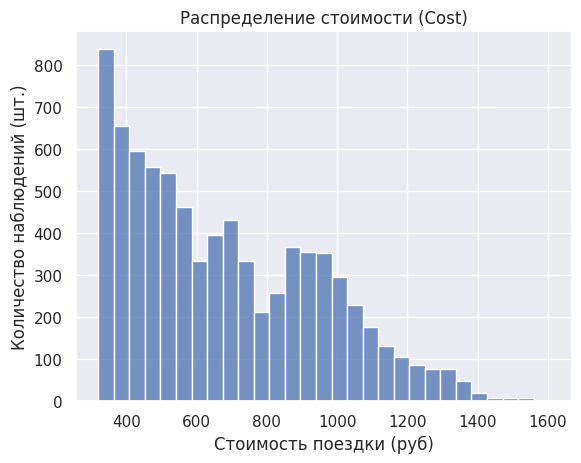

In [ ]:
sns.set(style='darkgrid')
sns.histplot(data['Cost'])
plt.title('Распределение стоимости (Cost)')
plt.xlabel('Стоимость поездки (руб)')
plt.ylabel('Количество наблюдений (шт.)')
plt.show()

В связи с высокой асимметрией распределения стоимости поездок и с целью получения более удобной экономической интерпретации коэффициентов давайте прологарифмируем зависимую переменную. Использование логарифма стоимости позволяет интерпретировать оценки коэффициентов как приближённые процентные изменения цены при изменении объясняющих переменных.

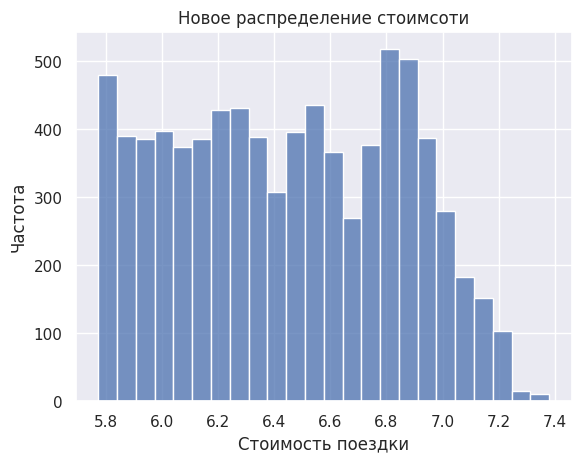

In [ ]:
data['Cost1'] = np.log1p(data['Cost'])
sns.histplot(data['Cost1'])
plt.title('Новое распределение стоимсоти')
plt.xlabel('Стоимость поездки')
plt.ylabel('Частота')
plt.show()

Теперь посмотрим на выбросы

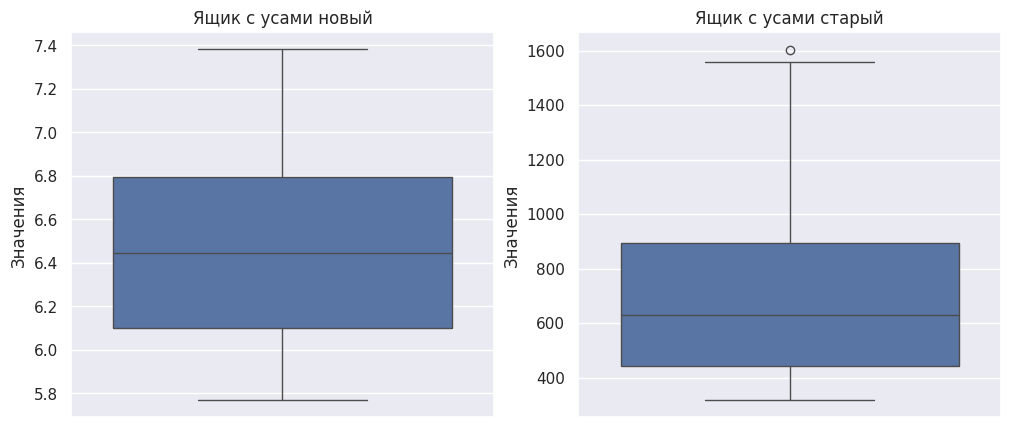

In [ ]:
plt.figure(figsize=[12,5])
plt.subplot(1,2,1)
sns.boxplot(data['Cost1'])
plt.ylabel('Значения')
plt.title('Ящик с усами новый')
plt.subplot(1,2,2)
sns.boxplot(data['Cost'])
plt.ylabel('Значения')
plt.title('Ящик с усами старый')
plt.show()


После логарифмирования стало заметно лучше!

####Спрос (Demand)

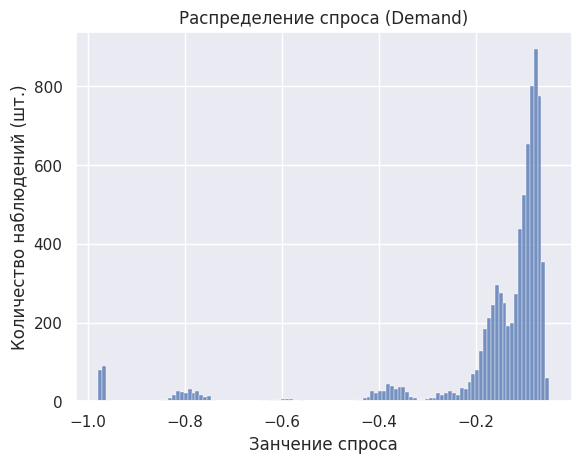

In [ ]:
sns.histplot(data['Demand'])
plt.title('Распределение спроса (Demand)')
plt.xlabel('Занчение спроса')
plt.ylabel('Количество наблюдений (шт.)')
plt.show()

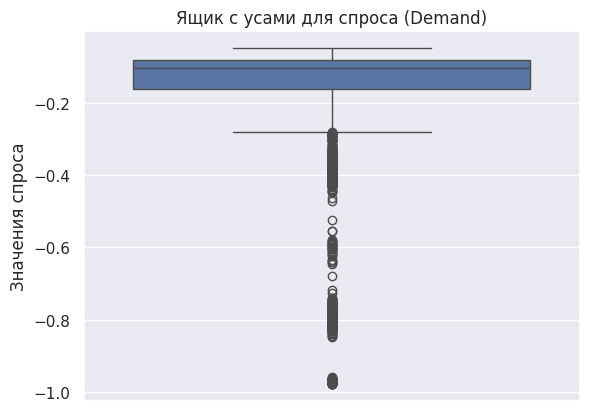

In [ ]:
sns.boxplot(data['Demand'])
plt.ylabel('Значения спроса')
plt.title('Ящик с усами для спроса (Demand)')
plt.show()

Видим очень много выбросов

Удаляем выбросы с помощью квантилей

In [ ]:
Q1 = data['Demand'].quantile(0.25)
Q3 = data['Demand'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['Demand'] >= lower) & (data['Demand'] <= upper)].copy()

Смотрим, на сколько теперь выражены выбросы

In [ ]:
data.shape

(7131, 11)

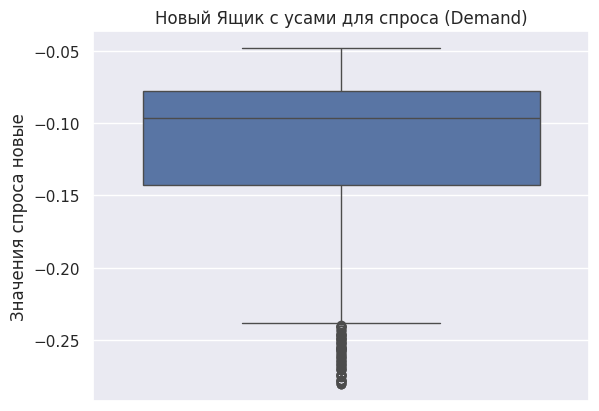

In [ ]:
sns.boxplot(data['Demand'])
plt.ylabel('Значения спроса новые')
plt.title('Новый Ящик с усами для спроса (Demand)')
plt.show()

Стало лучше!

####Длительность поездки (Length of the trip)

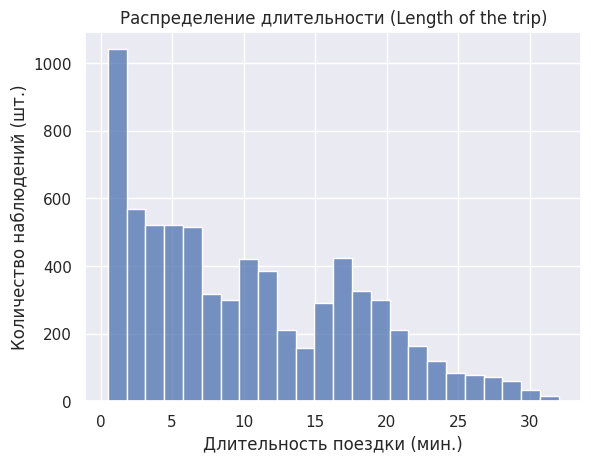

In [ ]:
sns.histplot(data['Length of the trip'])
plt.title('Распределение длительности (Length of the trip)')
plt.xlabel('Длительность поездки (мин.)')
plt.ylabel('Количество наблюдений (шт.)')
plt.show()

Данные так же смещены, можем применить логарифмирование

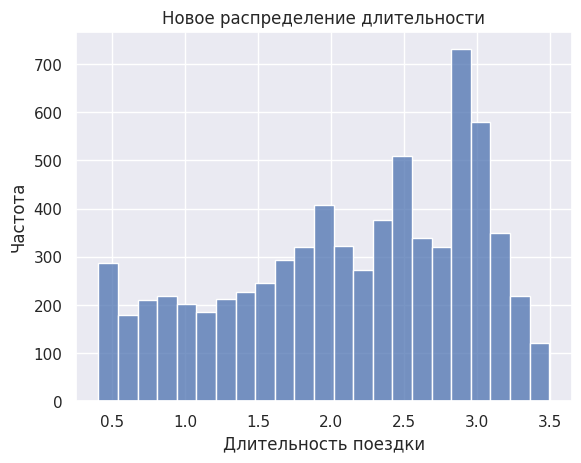

In [ ]:
data['Length of the trip1'] = np.log1p(data['Length of the trip'])
sns.histplot(data['Length of the trip1'])
plt.title('Новое распределение длительности')
plt.xlabel('Длительность поездки')
plt.ylabel('Частота')
plt.show()

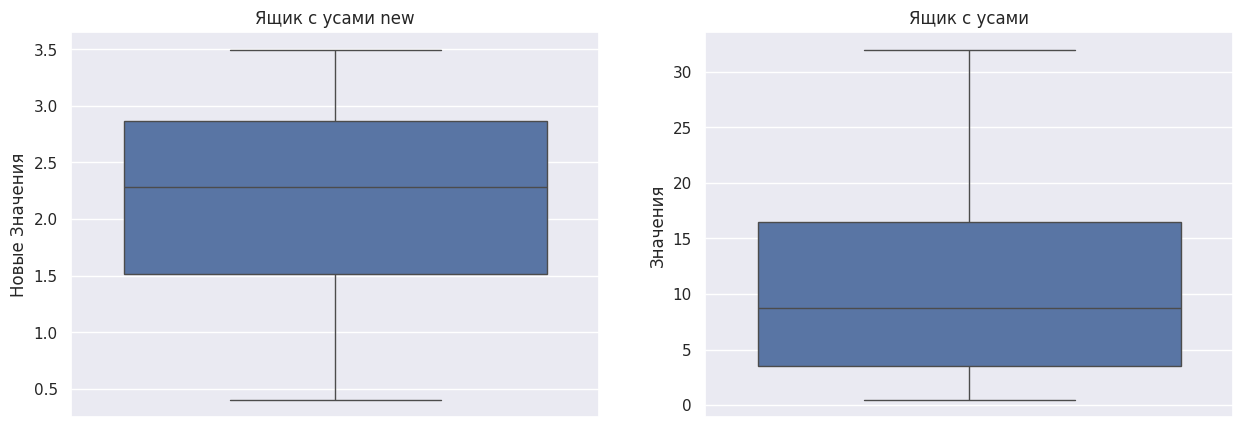

In [ ]:
plt.figure(figsize=[15,5])
plt.subplot(1,2,1)
sns.boxplot(data['Length of the trip1'])
plt.ylabel('Новые Значения')
plt.title('Ящик с усами new')
plt.subplot(1,2,2)
sns.boxplot(data['Length of the trip'])
plt.ylabel('Значения')
plt.title('Ящик с усами')
plt.show()

Логарифмирование помогло.

###Анализ dummy-переменных



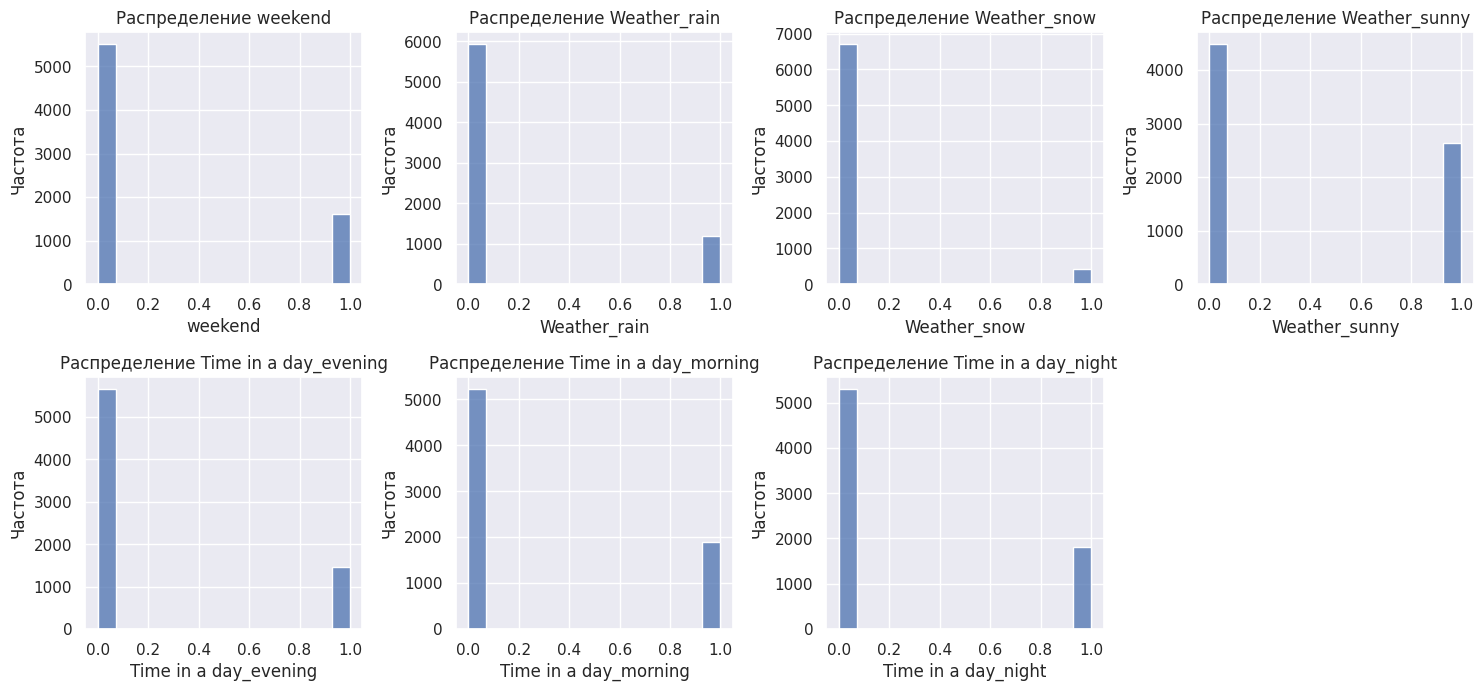

In [ ]:
k=1
plt.figure(figsize=(15, 10))
for i in ['weekend','Weather_rain','Weather_snow','Weather_sunny','Time in a day_evening','Time in a day_morning','Time in a day_night']:
  plt.subplot(3,4,k)
  sns.histplot(data[i])
  plt.title('Распределение '+i)
  plt.ylabel('Частота')
  plt.xlabel(i)
  plt.tight_layout()
  k+=1
plt.show()

###Анализ линейной зависимости переменных.

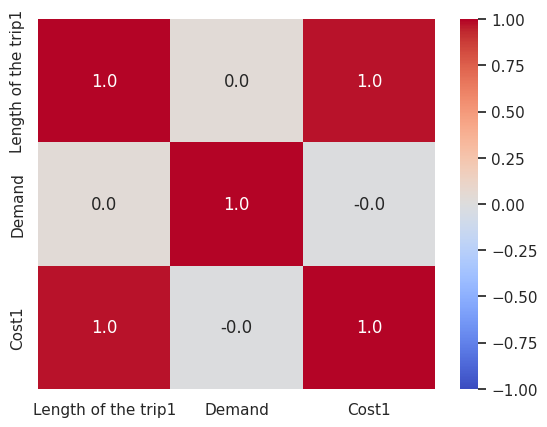

In [ ]:
sns.heatmap(data[['Length of the trip1','Demand','Cost1']].corr(numeric_only=True), annot=True, fmt = '0.1f', vmin=-1, vmax=1, center= 0, cmap= 'coolwarm')
plt.show()

Мы получили ожидаемый результат, который логично интерпретируется:
1. Корредяция между `log(Cost)` и `log(Length of the trip)` = 1\
  Логарифм стоимости поездки и логарифм её длины практически линейно связаны. Это указывает на то, что увеличение длины поездки сопровождается пропорциональным ростом стоимости, что полностью соответствует логике тарифообразования в такси.
2. Корреляция между `Demand` и `log(Cost)` близка к нулю.\
Низкая парная корреляция между показателем спроса и логарифмом стоимости не означает отсутствия влияния спроса на цену. Это лишь указывает на то, что влияние спроса может проявляться нелинейно!!!



###Итоговая используемая таблица и экономическая модель

In [ ]:
data['Cost']=data['Cost1']
data['Length of the trip']=data['Length of the trip1']
data=data[['Length of the trip','Demand','Cost','weekend','Weather_rain','Weather_snow','Weather_sunny','Time in a day_evening','Time in a day_morning','Time in a day_night']]

In [ ]:
data.head()

,Length of the trip,Demand,Cost,weekend,Weather_rain,Weather_snow,Weather_sunny,Time in a day_evening,Time in a day_morning,Time in a day_night
0,2.804378,-0.210378,6.799341,1,0,0,0,1,0,0
1,0.616099,-0.083528,5.829369,0,0,0,0,0,0,1
2,3.008565,-0.072508,6.922600,0,0,0,1,0,1,0
4,2.001036,-0.065995,6.239025,0,0,0,0,0,0,1
5,2.470101,-0.089862,6.526023,0,1,0,0,0,0,1


##Реализация множественной линейной регрессии

In [ ]:
X = data.drop('Cost', axis=1)
X = sm.add_constant(X)
y = data['Cost']

In [ ]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                 1.546e+04
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:19:32   Log-Likelihood:                 7173.2
No. Observations:                7131   AIC:                        -1.433e+04
Df Residuals:                    7121   BIC:                        -1.426e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     5.37

In [ ]:
results_table = pd.DataFrame({
    "Coefficient": model.params,
    "Std. Error": model.bse,
    "t-stat": model.tvalues,
    "p-value": model.pvalues
})

results_table.to_excel("ols_coefficients.xlsx")

##Реализация множественной линейной регрессии, если бы у нас не было переменной `Demand`

In [ ]:
X = data.drop(['Demand','Cost'], axis=1)
X = sm.add_constant(X)
y = data['Cost']

In [ ]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                 1.714e+04
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:34:43   Log-Likelihood:                 7122.5
No. Observations:                7131   AIC:                        -1.423e+04
Df Residuals:                    7122   BIC:                        -1.417e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     5.41

In [ ]:
results_table1 = pd.DataFrame({
    "Coefficient": model.params,
    "Std. Error": model.bse,
    "t-stat": model.tvalues,
    "p-value": model.pvalues
})

results_table1.to_excel("ols_coefficients1.xlsx")